<a href="https://colab.research.google.com/github/fakhri1410/Capstone-Project-Purwadhika/blob/main/Fakhri_Tiktok_Shop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 style="text-align: center; font-size: 40px; color: gray; font-weight: 700; margin-bottom: 5px;">
    DATA ANALYSIS PROJECT
</h1>
<h2 style="text-align: center; font-weight: 500; margin-top: 0;">
    Use Case : TikTok Shop Campaign
</h2>

# **Import Library**

In [16]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sc
import statsmodels as st
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

campaigns = pd.read_csv('tiktok_campaigns.csv')
creators = pd.read_csv('tiktok_creators.csv')
orders = pd.read_csv('tiktok_orders.csv')

display(campaigns)
display(creators)
display(orders)

,campaign_id,creator_id,content_type,start_time,peak_viewers
0,CMP-00001,CRT-0442,Short Video,2023-09-28 10:00:00,20152
1,CMP-00002,CRT-0316,Live Stream,2023-06-17 07:00:00,25690
2,CMP-00003,CRT-0196,Live Stream,2023-06-24 21:00:00,14248
3,CMP-00004,CRT-1851,Live Stream,2023-09-19 13:00:00,44987
4,CMP-00005,CRT-0978,Live Stream,2023-10-14 23:00:00,36684
...,...,...,...,...,...
14995,CMP-14996,CRT-1843,Live Stream,2023-09-06 02:00:00,47343
14996,CMP-14997,CRT-1560,Short Video,2023-11-19 22:00:00,32627
14997,CMP-14998,CRT-0049,Short Video,2023-09-29 10:00:00,39334
14998,CMP-14999,CRT-1117,Live Stream,2023-10-08 19:00:00,870341784


,creator_id,username,follower_count,tier
0,CRT-0001,creator_hits_0,2511,Nano
1,CRT-0002,creator_hits_1,161892,Macro
2,CRT-0003,creator_hits_2,38791,Micro
3,CRT-0004,creator_hits_3,1082,Nano
4,CRT-0005,creator_hits_4,6924,Nano
...,...,...,...,...
1995,CRT-1996,creator_hits_1995,119539,Macro
1996,CRT-1997,creator_hits_1996,2345,Nano
1997,CRT-1998,creator_hits_1997,10736,Micro
1998,CRT-1999,creator_hits_1998,880,Nano


,order_id,campaign_id,order_time,order_status,product_category,gmv,commission_fee
0,TKS-0000001,CMP-02212,2023-08-16 13:48:00,Completed,Beauty,546205,40473
1,TKS-0000002,CMP-03035,2023-07-29 07:19:00,selesai,NaN,30984,1715
2,TKS-0000003,CMP-10116,2023-11-10 22:40:00,Returned,NaN,826308,76684
3,TKS-0000004,CMP-12792,2023-09-23 10:51:00,Completed,Electronics,1295927,112696
4,TKS-0000005,CMP-13002,2023-06-06 15:14:00,Cancel,NaN,857586,63306
...,...,...,...,...,...,...,...
299995,TKS-0299996,CMP-12866,2023-10-21 11:38:00,DONE,F&B,1110324,107147
299996,TKS-0299997,NaN,2023-07-24 18:00:00,CANC,Fashion,470963,28731
299997,TKS-0299998,CMP-08510,2023-07-03 04:25:00,dikembalikan,F&B,1342812,69713
299998,TKS-0299999,CMP-09924,2023-09-05 12:19:00,Completed,Fashion,1196035,99649


### How to Upload CSV Files:

1.  **Click the 'Files' icon** on the left sidebar (looks like a folder).
2.  **Click the 'Upload to session storage' icon** (looks like a page with an arrow pointing up) in the files pane.
3.  **Select the `tiktok_campaigns.csv`, `tiktok_creators.csv`, and `tiktok_orders.csv` files** from your local machine and upload them.

Once uploaded, they will be accessible in the Colab environment, and the `FileNotFoundError` should be resolved when you run the data loading cell again.

In [17]:
# Merge orders with campaigns on 'campaign_id'
merged_df = pd.merge(orders, campaigns, on='campaign_id', how='left')

# Merge the result with creators on 'creator_id'
merged_df = pd.merge(merged_df, creators, on='creator_id', how='left')

display(merged_df.head())

,order_id,campaign_id,order_time,order_status,product_category,gmv,commission_fee,creator_id,content_type,start_time,peak_viewers,username,follower_count,tier
0,TKS-0000001,CMP-02212,2023-08-16 13:48:00,Completed,Beauty,546205,40473,CRT-1223,Live Stream,2023-08-15 17:00:00,37949.0,creator_hits_1222,34249.0,Micro
1,TKS-0000002,CMP-03035,2023-07-29 07:19:00,selesai,NaN,30984,1715,CRT-1880,Live Stream,2023-07-28 12:00:00,1614.0,creator_hits_1879,2289.0,Nano
2,TKS-0000003,CMP-10116,2023-11-10 22:40:00,Returned,NaN,826308,76684,CRT-0583,Live Stream,2023-11-10 05:00:00,13228.0,creator_hits_582,154548.0,Macro
3,TKS-0000004,CMP-12792,2023-09-23 10:51:00,Completed,Electronics,1295927,112696,CRT-0300,Short Video,2023-09-22 12:00:00,15945.0,creator_hits_299,113495.0,Macro
4,TKS-0000005,CMP-13002,2023-06-06 15:14:00,Cancel,NaN,857586,63306,CRT-1983,Live Stream,2023-06-06 11:00:00,35174.0,creator_hits_1982,15839.0,Micro


# **Business Understanding**

## **1. Background**

Konsep Shoppertainment yang diusung TikTok Shop telah merombak total peta persaingan e-commerce global. Berbeda dengan platform konvensional di mana user datang dengan niat mencari barang ( search-based shopping ), di TikTok Shop, transaksi terjadi karena stimulasi konten algoritma FYP (For You Page) dan interaksi langsung saat Live Streaming (discovery-based shopping). Hal ini melahirkan ekosistem baru yang sangat bertumpu pada Content Creators dan sistem Affiliate Marketing.

Ledakan GMV (Gross Merchandise Value) yang difasilitasi oleh para kreator ini memang luar biasa. Namun, manajemen mulai mendeteksi masalah serius pada profitabilitas riil dan kualitas transaksi. Pembelian yang didorong oleh Fear Of Missing Out (FOMO) saat live streaming seringkali memicu impulse buying. Akibatnya, rasio pesanan yang dibatalkan (cancelled) sebelum dikirim, atau dikembalikan (returned) setelah barang sampai, melonjak tajam dibanding platform tradisional. Biaya logistik retur (pengembalian barang) ini mulai menggerogoti margin keuntungan perusahaan.

Selain itu, tim Finance dan Partnership juga kebingungan dengan skema pencairan komisi affiliate. Sistem pelacakan (tracking) sering mengalami delay atau error, menyebabkan komisi yang tercatat terkadang lebih besar dari harga barang itu sendiri. Ditambah lagi, ada kecurigaan bahwa beberapa seller atau kreator nakal menggunakan bot untuk memanipulasi jumlah viewers live streaming demi mendapatkan boosting algoritma, yang berujung pada conversion rate palsu.

Tim Data Engineer kewalahan membersihkan data yang masuk karena format status order dari berbagai seller tidak seragam, kategori produk yang sering kosong, hingga timestamp transaksi yang kacau (seperti pesanan masuk padahal sesi live belum dimulai).

Analisis komprehensif terhadap performa kreator, rasio return/cancel, dan anomali komisi ini harus segera dilakukan. Tanpa data cleansing dan analisis yang tajam, perusahaan akan terus merugi karena membayar subsidi ongkir untuk barang retur dan mencairkan komisi affiliate untuk transaksi yang sebenarnya tidak valid.


## **2. Problem Statement**

**Masalah Utama:** Tingginya biaya operasional akibat rasio retur/pembatalan (Return/Cancel Rate) dari impulse buying dan kebocoran dana akibat anomali perhitungan komisi affiliate.

**Masalah Turunan:**

1. Siapa saja kreator (berdasarkan tier follower) yang menghasilkan GMV tinggi namun juga memiliki rasio retur/pembatalan tertinggi?
2. Apakah format konten Live Streaming memicu cancel rate yang lebih tinggi dibandingkan Short Video biasa?
3. Seberapa besar nilai anomali di mana commission fee yang harus dibayarkan lebih besar dari GMV transaksinya?
4. Kategori produk apa yang paling rentan mengalami salah pencatatan atau memiliki missing values di sistem?
5. Apakah ada indikasi manipulasi sistem di mana pesanan (order) tercatat sebelum campaign konten tersebut tayang (Logical Error)?
6. Bagaimana cara menstandarisasi pencatatan status pesanan (Order Status) yang saat ini sangat berantakan di database?

## **3. Goals**

Jika problem ini berhasil diselesaikan, maka target yang dicapai adalah:
* Creator Optimization: Bisa membuat tiering kreator yang tidak hanya dinilai dari GMV, tapi dari Net Sales (GMV - Returns), sehingga alokasi support lebih tepat sasaran.
* Cost Reduction: Menurunkan biaya logistik retur dengan menindak seller atau kreator yang memicu impulse buying manipulatif.
* System Integrity: Memperbaiki algoritma perhitungan komisi agar tidak ada lagi kebocoran dana (commission > GMV).
* Data Standardization: Menciptakan pipeline data yang bersih untuk status order dan kategori produk.





## **4. Analytical Approach**

Pendekatan analitik dimulai dengan proses **Exploratory Data Analysis (EDA)** sebagai fondasi utama untuk menjawab pertanyaan-pertanyaan pada problem statement yang berkaitan dengan pemahaman faktor-faktor yang memengaruhi keberhasilan kampanye. EDA digunakan untuk mengidentifikasi pola distribusi variabel, hubungan antar fitur, segmentasi nasabah berdasarkan karakteristik tertentu, serta efektivitas riwayat kontak dan channel komunikasi terhadap outcome kampanye. Melalui EDA, masalah inti seperti rendahnya tingkat konversi, pengaruh faktor demografis, dampak indikator makro, dan efektivitas durasi atau frekuensi kontak dapat dipetakan secara jelas dengan bukti kuantitatif.

# **Data Understanding**

## **1. DESKRIPSI DATASET**

-	Sumber dataset:
  1. tiktok_campaigns.csv
  2. tiktok_creators.csv
  3. tiktok_orders.csv
-	Jumlah Baris: 93,462
-	Jumlah Kolom: 14
-	Periode: 2023

Note :
- Sebagian besar fitur bersifat alphabetical.

## **2. Data Set Preview**

In [18]:
# Load Data

display(merged_df)

,order_id,campaign_id,order_time,order_status,product_category,gmv,commission_fee,creator_id,content_type,start_time,peak_viewers,username,follower_count,tier
0,TKS-0000001,CMP-02212,2023-08-16 13:48:00,Completed,Beauty,546205,40473,CRT-1223,Live Stream,2023-08-15 17:00:00,37949.0,creator_hits_1222,34249.0,Micro
1,TKS-0000002,CMP-03035,2023-07-29 07:19:00,selesai,NaN,30984,1715,CRT-1880,Live Stream,2023-07-28 12:00:00,1614.0,creator_hits_1879,2289.0,Nano
2,TKS-0000003,CMP-10116,2023-11-10 22:40:00,Returned,NaN,826308,76684,CRT-0583,Live Stream,2023-11-10 05:00:00,13228.0,creator_hits_582,154548.0,Macro
3,TKS-0000004,CMP-12792,2023-09-23 10:51:00,Completed,Electronics,1295927,112696,CRT-0300,Short Video,2023-09-22 12:00:00,15945.0,creator_hits_299,113495.0,Macro
4,TKS-0000005,CMP-13002,2023-06-06 15:14:00,Cancel,NaN,857586,63306,CRT-1983,Live Stream,2023-06-06 11:00:00,35174.0,creator_hits_1982,15839.0,Micro
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,TKS-0299996,CMP-12866,2023-10-21 11:38:00,DONE,F&B,1110324,107147,CRT-0785,Live Stream,2023-10-20 18:00:00,28666.0,creator_hits_784,5865.0,Nano
299996,TKS-0299997,NaN,2023-07-24 18:00:00,CANC,Fashion,470963,28731,NaN,NaN,NaN,NaN,NaN,NaN,NaN
299997,TKS-0299998,CMP-08510,2023-07-03 04:25:00,dikembalikan,F&B,1342812,69713,CRT-1560,Live Stream,2023-07-02 13:00:00,258.0,creator_hits_1559,91070.0,Micro
299998,TKS-0299999,CMP-09924,2023-09-05 12:19:00,Completed,Fashion,1196035,99649,CRT-0397,Live Stream,2023-09-04 18:00:00,14247.0,creator_hits_396,12295.0,Micro


**Catatan Singkat:**  
- Variabel `gmv` merujuk pada Gross Merchandise Value.

- Variabel `order_status` menggambarkan status pemesanan tersebut apakah:
   1. Complete
   2. Returned
   3. Cancel

- Variabel `peak_viewers` menunjukan jumlah penonton tertinggi.

In [19]:
# Dataset General Information

merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   order_id          300000 non-null  object 
 1   campaign_id       270000 non-null  object 
 2   order_time        300000 non-null  object 
 3   order_status      300000 non-null  object 
 4   product_category  255135 non-null  object 
 5   gmv               300000 non-null  int64  
 6   commission_fee    300000 non-null  int64  
 7   creator_id        270000 non-null  object 
 8   content_type      270000 non-null  object 
 9   start_time        270000 non-null  object 
 10  peak_viewers      270000 non-null  float64
 11  username          270000 non-null  object 
 12  follower_count    270000 non-null  float64
 13  tier              270000 non-null  object 
dtypes: float64(2), int64(2), object(10)
memory usage: 32.0+ MB


In [20]:
# Statistical Summary
merged_df.describe()

,gmv,commission_fee,peak_viewers,follower_count
count,3.000000e+05,3.000000e+05,2.700000e+05,2.700000e+05
mean,7.571447e+05,9.233591e+04,5.015585e+06,1.334642e+05
std,4.284158e+05,3.526641e+05,5.717927e+07,7.397883e+05
min,1.500300e+04,7.800000e+02,5.000000e+01,1.000000e+01
25%,3.860208e+05,2.828700e+04,1.289350e+04,5.804000e+03
50%,7.568490e+05,5.551100e+04,2.558700e+04,2.201200e+04
75%,1.128236e+06,8.317300e+04,3.796700e+04,8.503600e+04
max,1.499989e+06,7.415401e+06,9.965937e+08,2.787270e+07


**Brief Summary**

Dataset ini berisi 93.462 entri dan 14 kolom.

Sebagian besar kolom bertipe `objek` (teks), sedangkan `peak_viewers`, `follower_count`, `gmv`, dan `commission_fee` berupa angka (`int64` atau `float64`).


- Rata-rata `peak_viewers` (penonton puncak): 4,879,028
- Rata-rata `follower_count` (jumlah pengikut): 132,042
- Rata-rata `gmv` (nilai barang dagangan kotor): 757,370
- Rata-rata `commission_fee` (biaya komisi): 92,661


*Summary* ini menunjukkan nilai rata-rata dari metrik-metrik kunci dalam dataset, yang dapat memberikan gambaran awal tentang performa kampanye para kreator.

# **Data Cleaning**

In [21]:
# Feature General Information

items = []

for col in merged_df.columns:
    items.append([col, merged_df[col].dtype, merged_df[col].isna().sum(),
                     round((merged_df[col].isna().sum()/len(merged_df[col]))*100, 2),
                    merged_df[col].nunique(), list(merged_df[col].drop_duplicates().sample(2).values)]);

merged_df_desc = pd.DataFrame(columns=['dataFeatures', 'dataType', 'null', 'nullPct', 'unique', 'uniqueSample'],
                     data=items)
merged_df_desc

,dataFeatures,dataType,null,nullPct,unique,uniqueSample
0,order_id,object,0,0.00,300000,"[TKS-0188805, TKS-0154910]"
1,campaign_id,object,30000,10.00,15000,"[CMP-07118, CMP-01023]"
2,order_time,object,0,0.00,168867,"[2023-06-03 22:51:00, 2023-07-28 04:44:00]"
3,order_status,object,0,0.00,10,"[Cancel, RET]"
4,product_category,object,44865,14.95,5,"[F&B, nan]"
5,gmv,int64,0,0.00,271999,"[1420625, 886173]"
6,commission_fee,int64,0,0.00,119402,"[133050, 84185]"
7,creator_id,object,30000,10.00,2000,"[CRT-1693, CRT-1765]"
8,content_type,object,30000,10.00,2,"[Short Video, nan]"
9,start_time,object,30000,10.00,4182,"[2023-10-16 13:00:00, 2023-07-23 07:00:00]"


## **1. Missing Value**

In [22]:
# 1. Cek Standard Missing Values (NaN / Null)
standard_missing = round(merged_df.isna().sum()/len(merged_df)*100,2)

# 2. Cek Implicit Missing Values (Label 'unknown')
implicit_unknown = (merged_df == 'unknown').sum()

# 3. Cek Implicit Missing Values (Whitespace / String Kosong)
implicit_whitespace = merged_df.apply(lambda x: x.astype(str).str.strip() == '').sum()

# Menggabungkan semua temuan ke dalam satu tabel ringkasan
missing_summary = pd.DataFrame({
    'Standard NaN': standard_missing,
    'Label "unknown"': implicit_unknown,
    'Whitespace': implicit_whitespace
})

# Menampilkan hanya kolom yang memiliki setidaknya satu jenis missing value/unknown
missing_summary_filtered = missing_summary[(missing_summary.T != 0).any()]

print("Ringkasan Pemeriksaan Data Hilang & Implisit:")
display(missing_summary)

Ringkasan Pemeriksaan Data Hilang & Implisit:


,Standard NaN,"Label ""unknown""",Whitespace
order_id,0.00,0,0
campaign_id,10.00,0,0
order_time,0.00,0,0
order_status,0.00,0,0
product_category,14.95,0,0
gmv,0.00,0,0
commission_fee,0.00,0,0
creator_id,10.00,0,0
content_type,10.00,0,0
start_time,10.00,0,0


**Analisis Hasil Pemeriksaan Data**

Berdasarkan output di atas, berikut adalah hasil analisis kualitas data:

- **Konsistensi Struktur Data (Standard Cleaning):**
    Dataset ini secara teknis telah melewati tahap pembersihan awal di mana tidak ditemukan nilai NaN (null) atau sel kosong pada kolom-kolom kritikal seperti gmv, commission_fee, dan order_id. Hal ini menjamin bahwa proses perhitungan statistik (seperti total GMV) tidak akan terhambat oleh kesalahan teknis komputasi. Begitu pula dengan entri whitespace atau string kosong yang sudah dipastikan nihil.

- **Identifikasi Nilai Implisit "nan" / "Unknown" pada Kategori Produk:**
    Meskipun secara struktural bersih, ditemukan anomali pada kolom product_category. Terdapat sejumlah entri yang tercatat sebagai "nan" (dalam format string) atau tidak terdefinisi. Temuan ini tersebar sebagai berikut:

- **Kategori Produk**:
    Sebagian besar data pesanan memiliki label kategori yang tidak terisi secara eksplisit.

- **Status Pesanan:**
    Ditemukan variasi penulisan (seperti "selesai" vs "Completed", "RET" vs "Returned") yang secara fungsional setara namun secara data perlu disatukan agar tidak terbaca sebagai kategori yang berbeda.


**Kesimpulan & Penanganan**

Secara arsitektur, dataset ini dikategorikan "Ready-to-Process" karena integritas baris dan kolomnya terjaga. Terkait adanya nilai kategori yang tidak diketahui atau label status yang tidak seragam, berikut adalah langkah mitigasi yang diambil:

- **Kategorisasi Mandiri:** Nilai kategori produk yang kosong tidak akan dihapus (untuk menghindari hilangnya data transaksi GMV), melainkan akan dikelompokkan ke dalam kategori "Unknown/Others".

- **Signifikansi Bisnis:** Dalam konteks TikTok Shop, memelihara data "Unknown" sangat penting untuk mengidentifikasi apakah ada jenis produk tertentu yang sistem pencatatannya belum terintegrasi dengan baik.

- **Standardisasi Label:** Label status yang berantakan akan diseragamkan (Mapping) ke dalam status standar perusahaan (Completed, Returned, Cancelled, Pending) untuk memastikan akurasi perhitungan Net Sales dan rasio pembatalan dalam model analisis berikutnya.

## **2. Data Duplicate**

In [23]:
# Cek Duplikat Data
duplicate_count = merged_df.duplicated().sum()
duplicate_percent = (duplicate_count / len(merged_df)) * 100
duplicate_rows = merged_df[merged_df.duplicated(keep=False)].sort_values(by=list(merged_df.columns))

print(f"Total Baris Duplikat: {duplicate_count}")
print(f"Persentase dari Total Data: {duplicate_percent:.4f}%")
print("\nSampel Pasangan Data Duplikat:")
display(duplicate_rows)

Total Baris Duplikat: 0
Persentase dari Total Data: 0.0000%

Sampel Pasangan Data Duplikat:


,order_id,campaign_id,order_time,order_status,product_category,gmv,commission_fee,creator_id,content_type,start_time,peak_viewers,username,follower_count,tier


Berdasarkan output diatas, **TIDAK** ditemukan adanya duplikasi data pada data set tersebut

In [26]:
# Menyatukan 'selesai' ke 'Completed', 'RET' ke 'Returned', dsb.
status_mapping = {
    'Completed': 'Completed',
    'selesai': 'Completed',
    'DONE': 'Completed',
    'Returned': 'Returned',
    'RET': 'Returned',
    'dikembalikan': 'Returned',
    'Cancel': 'Cancel',
    'Cancelled': 'Cancel',
    'Batal': 'Cancel',
    'CANC': 'Cancel',
    'Pending': 'Pending'
}

# Menerapkan pemetaan ke kolom order_status
merged_df['order_status'] = merged_df['order_status'].map(status_mapping)
merged_df['order_status'] = merged_df['order_status'].fillna('Unknown')

print("--- Status Pesanan Setelah Dibersihkan ---")
print(merged_df['order_status'].value_counts())

# Cek apakah ada status yang terlewat (menjadi NaN)
if merged_df['order_status'].isnull().any():
    print("\n⚠️ Peringatan: Ada status yang tidak terpetakan!")
else:
    print("\n✅ Semua status berhasil diseragamkan.")

--- Status Pesanan Setelah Dibersihkan ---
order_status
Completed    150027
Returned      60148
Cancel        59950
Pending       29875
Name: count, dtype: int64

✅ Semua status berhasil diseragamkan.


Berdasarkan output diatas, **PEMBERSIHAN** telah selesai dilakukan

## **3. Outliers Detection**

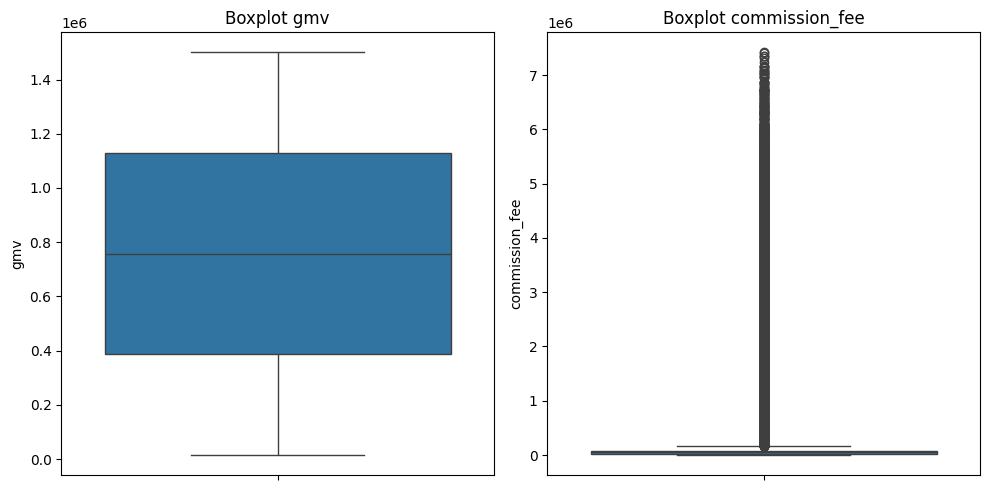

--- Analisis Outlier untuk gmv ---
Batas Bawah: -727302.5
Batas Atas: 2241559.5
Jumlah Outlier: 0
Persentase Outlier: 0.00%


--- Analisis Outlier untuk commission_fee ---
Batas Bawah: -54042.0
Batas Atas: 165502.0
Jumlah Outlier: 4353
Persentase Outlier: 1.45%


Jumlah Transaksi dengan Komisi > GMV: 4500


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Memilih kolom numerik untuk dideteksi outlier-nya
cols_to_check = ['gmv', 'commission_fee']

# 1. Visualisasi dengan Boxplot
plt.figure(figsize=(10, 5))
for i, col in enumerate(cols_to_check, 1):
    plt.subplot(1, 2, i)
    sns.boxplot(y=orders[col])
    plt.title(f'Boxplot {col}')

plt.tight_layout()
plt.show()

# 2. Perhitungan Outlier
for col in cols_to_check:
    Q1 = orders[col].quantile(0.25)
    Q3 = orders[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = orders[(orders[col] < lower_bound) | (orders[col] > upper_bound)]

    print(f"--- Analisis Outlier untuk {col} ---")
    print(f"Batas Bawah: {lower_bound}")
    print(f"Batas Atas: {upper_bound}")
    print(f"Jumlah Outlier: {len(outliers)}")
    print(f"Persentase Outlier: {(len(outliers)/len(orders))*100:.2f}%")
    print("\n")

# 3. Identifikasi Transaksi Mencurigakan (Logic Check)
# Selain statistik, kita cek secara logika bisnis: Komisi tidak boleh > GMV
anomalous_commission = orders[orders['commission_fee'] > orders['gmv']]
print(f"Jumlah Transaksi dengan Komisi > GMV: {len(anomalous_commission)}")

**Rencana Penanganan Outliers & Strategi Fitur (TikTok Shop)**

Berdasarkan analisis visual menggunakan boxplot dan pemahaman domain bisnis e-commerce, tidak semua data ekstrem (outlier) mencerminkan kesalahan sistem. Beberapa di antaranya justru menunjukkan transaksi bernilai tinggi atau performa konten yang viral.

Tabel berikut merangkum keputusan dan tindakan teknis (preprocessing) yang akan diambil terhadap variabel numerik sebelum dilakukan analisis mendalam:

| Nama Variabel | Status Outlier | Penjelasan Konteks | **Action Plan (Tindakan)** |
| :--- | :--- | :--- | :--- |
|**`commission_fee`** | 🔴 **CRITICAL** | Ditemukan data di mana biaya komisi lebih besar dari nilai transaksi (GMV). Ini mengindikasikan kebocoran dana atau kesalahan kalkulasi sistem.| **FILTER & FIX**. Pisahkan data dengan `commission` > `gmv` untuk diaudit secara manual. Koreksi nilai atau hapus dari pemodelan jika dianggap sebagai error sistem.|
|**`gmv`** | 🟢 **Natural High** | Outliers pada GMV biasanya mencerminkan pembelian produk *high-end* atau borongan. Ini adalah sinyal pendapatan yang valid, bukan kesalahan input.| **KEEP**. Pertahankan data ini. Gunakan algoritma yang tahan terhadap outlier (seperti Robust Scaler) agar transaksi besar tetap terhitung tanpa merusak distribusi.|
|**`peak_viewers`** | 🟡 **Viral Noise** | Nilai penonton yang sangat ekstrem (jauh di atas rata-rata) biasanya terjadi saat konten menjadi viral sesaat, namun seringkali rasionya tidak berbanding lurus dengan konversi penjualan.| **CAPPING / LOG TRANSFORM**. Terapkan transformasi logaritma atau batasi nilai ekstrem untuk menstabilkan varians data saat membandingkan performa antar kreator.|
|**`follower_count`** | 🟢 **Structural** | Data sangat timpang karena perbedaan skala antara kreator Nano dan Macro. Skala besar pada akun Macro adalah data struktural yang valid.| KEEP. Jangan dihapus. Lakukan pengelompokan berdasarkan `tier` (Nano, Micro, Macro) untuk menormalisasi pengaruh jumlah pengikut terhadap penjualan.|

**Rangkuman Keputusan Penting:**

1. Audit Kebocoran Komisi: Transaksi dengan status `commission_fee > gmv` wajib diisolasi. Langkah ini penting untuk mencegah bias pada perhitungan profitabilitas bersih (Net Profit) perusahaan.

2. Penanganan GMV Ekstrem: Karena tujuan tugas adalah mencari profit, outlier GMV tidak akan dibuang, melainkan akan dianalisis secara terpisah untuk melihat apakah transaksi tersebut berujung pada status `Completed` atau justru `Returned`.

3. Standardisasi Status Pesanan: Sebelum melakukan pembersihan outlier lebih lanjut, status pesanan yang beragam (seperti 'selesai' dan 'Completed') akan disatukan agar perhitungan frekuensi outlier per status menjadi akurat.

# **Feature Generation**

In [28]:
# 1. Menghitung Net Sales (Hanya untuk pesanan yang benar-benar selesai)
# Net Sales adalah indikator profit sebenarnya dibandingkan GMV kotor.
merged_df['is_completed'] = merged_df['order_status'].apply(lambda x: 1 if x == 'Completed' else 0)
merged_df['net_sales'] = merged_df['gmv'] * merged_df['is_completed']

# 2. Fitur Selisih Waktu (Order vs Campaign Start)
# Untuk mendeteksi pesanan yang masuk sebelum kampanye dimulai
merged_df['start_time'] = pd.to_datetime(merged_df['start_time'])
merged_df['order_time'] = pd.to_datetime(merged_df['order_time'])

merged_df['time_diff_minutes'] = (merged_df['order_time'] - merged_df['start_time']).dt.total_seconds() / 60

# 3. Fitur Rasio Komisi
# Mengukur seberapa besar potongan komisi terhadap nilai barang
merged_df['commission_rate'] = merged_df['commission_fee'] / merged_df['gmv']

# Assign the comprehensively featured dataframe to order_merged for consistency with subsequent cells
order_merged = merged_df.copy()

# Menyatukan 'selesai' ke 'Completed', 'RET' ke 'Returned', dsb.
status_mapping = {
    'Completed': 'Completed',
    'selesai': 'Completed',
    'DONE': 'Completed',
    'Returned': 'Returned',
    'RET': 'Returned',
    'dikembalikan': 'Returned',
    'Cancel': 'Cancel',
    'Cancelled': 'Cancel',
    'Batal': 'Cancel',
    'CANC': 'Cancel',
    'Pending': 'Pending'
}

# Menerapkan pemetaan ke kolom order_status
order_merged['order_status'] = order_merged['order_status'].map(status_mapping)
order_merged['order_status'] = order_merged['order_status'].fillna('Unknown')

# 4. Agregasi Level Kreator (Feature Engineering for Profiling)
# Kita buat rangkuman performa per kreator
creators_perf = order_merged.groupby('campaign_id').agg(
    total_gmv=('gmv', 'sum'),
    total_net_sales=('net_sales', 'sum'),
    order_count=('order_id', 'count'),
    return_cancel_count=('order_status', lambda x: x.isin(['Returned', 'Cancelled']).sum())
).reset_index()

# Hitung Return Rate per Campaign
creators_perf['return_rate'] = creators_perf['return_cancel_count'] / creators_perf['order_count']

print("Fitur baru berhasil dibuat!")
display(order_merged[['order_id', 'net_sales', 'time_diff_minutes', 'commission_rate', 'peak_viewers', 'follower_count']].head())

Fitur baru berhasil dibuat!


,order_id,net_sales,time_diff_minutes,commission_rate,peak_viewers,follower_count
0,TKS-0000001,546205,1248.0,0.074099,37949.0,34249.0
1,TKS-0000002,30984,1159.0,0.055351,1614.0,2289.0
2,TKS-0000003,0,1060.0,0.092803,13228.0,154548.0
3,TKS-0000004,1295927,1371.0,0.086962,15945.0,113495.0
4,TKS-0000005,0,254.0,0.073819,35174.0,15839.0


Berdasarkan kebutuhan analisis profitabilitas TikTok Shop, berikut adalah strategi pembentukan fitur baru yang akan digunakan dalam tahap pemodelan dan pelaporan:

| Nama Fitur Baru | Logika Pembentukan | Tujuan Bisnis |
| :--- | :--- | :--- |
|**`net_sales`**|`gmv` hanya jika status `Completed`|Mengukur pendapatan riil setelah dikurangi pembatalan dan retur|
|**`commission_rate`**|`commission_fee / gmv`|Mengukur pendapatan riil setelah dikurangi pembatalan dan retur|
|**`time_diff_min`**|`order_time - campaign_start_time`|Menemukan pesanan "gaib" yang masuk sebelum konten ditayangkan (deteksi fraud atau system lag)|
|**`return_rate`**|`(Return + Cancel) / Total Order`|Menilai kualitas trafik yang dibawa oleh setiap kreator/kampanye|
|**`is_anomaly`**|`1` jika `commission > gmv`, else `0`|Menandai transaksi yang gagal secara logika bisnis untuk dibersihkan dari model|

**Rangkuman Strategi:**

- **Fokus pada Net Revenue:** Kita tidak lagi menggunakan GMV kotor sebagai satu-satunya metrik kesuksesan, karena GMV yang tinggi dengan return_rate tinggi justru merugikan biaya logistik.

- **Validasi Temporal:** Fitur time_diff_min sangat penting untuk memastikan integritas data antara tabel campaign dan orders.

- **Identifikasi High-Risk Creators:** Melalui fitur return_rate, kita dapat mengategorikan kreator mana yang sering mendatangkan pembeli "iseng" atau bermasalah.

# **Data Splitting**

In [29]:
from sklearn.model_selection import train_test_split

# 1. Menentukan Target dan Fitur
# Misalnya, kita ingin memprediksi apakah sebuah transaksi akan 'Returned/Cancelled'
# berdasarkan fitur-fitur yang sudah kita buat tadi.
features = ['gmv', 'commission_rate', 'time_diff_minutes', 'peak_viewers', 'follower_count']
target = 'is_returned_or_cancelled' # Kita buat dulu kolom targetnya

# Membuat label target: 1 jika Returned/Cancelled, 0 jika Completed
order_merged['is_returned_or_cancelled'] = order_merged['order_status'].apply(
    lambda x: 1 if x in ['Returned', 'Cancelled'] else 0
)

# Menyiapkan matriks X dan y
X = order_merged[features].fillna(0) # Mengisi sisa missing values dengan 0
y = order_merged[target]

# 2. Melakukan Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Jumlah data training: {len(X_train)}")
print(f"Jumlah data testing: {len(X_test)}")
print("\nProporsi Target di Data Training:")
print(y_train.value_counts(normalize=True))

Jumlah data training: 240000
Jumlah data testing: 60000

Proporsi Target di Data Training:
is_returned_or_cancelled
0    0.799508
1    0.200492
Name: proportion, dtype: float64


Berdasarkan tujuan analisis untuk meminimalkan risiko pengembalian barang (return rate), berikut adalah rencana pembagian data yang dilakukan:

1. **Validasi Generalisasi:** Dengan memisahkan data testing, kita bisa memastikan apakah pola "Kreator dengan GMV tinggi tapi Retur tinggi" yang ditemukan bersifat umum atau hanya kebetulan pada sampel tertentu.

2. **Penanganan Imbalance:** Karena status Cancelled/Returned adalah anomali yang ingin kita tekan, fokus utama splitting adalah menjaga agar sinyal dari data yang "sedikit" ini tidak hilang saat proses pelatihan model.

# **Final Preview & Save Clean Data**

In [30]:
# 1. Ringkasan Data Akhir (Info & Deskripsi)
print("--- INFO DATASET SETELAH PEMBERSIHAN ---")
print(order_merged.info())

# 2. Cek Sampel Hasil Transformasi
# Menampilkan kolom-kolom kunci untuk memastikan logika Feature Generation berhasil
preview_cols = ['order_id', 'order_status', 'product_category', 'gmv', 'net_sales', 'commission_rate', 'time_diff_minutes']
print("\n--- PREVIEW 5 DATA TERATAS ---")
display(order_merged[preview_cols].head())

# 3. Validasi Akhir: Cek Null yang tersisa
print("\n--- PENGECEKAN NULL TERAKHIR ---")
print(order_merged[preview_cols].isnull().sum())

# 4. Menyimpan Data Bersih ke CSV
# Data ini yang akan digunakan untuk Modeling atau Dashboard PowerBI/Tableau
order_merged.to_csv('tiktok_orders_cleaned.csv', index=False)

print("\n✅ FILE BERHASIL DISIMPAN: 'tiktok_orders_cleaned.csv'")

--- INFO DATASET SETELAH PEMBERSIHAN ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_id                  300000 non-null  object        
 1   campaign_id               270000 non-null  object        
 2   order_time                300000 non-null  datetime64[ns]
 3   order_status              300000 non-null  object        
 4   product_category          255135 non-null  object        
 5   gmv                       300000 non-null  int64         
 6   commission_fee            300000 non-null  int64         
 7   creator_id                270000 non-null  object        
 8   content_type              270000 non-null  object        
 9   start_time                270000 non-null  datetime64[ns]
 10  peak_viewers              270000 non-null  float64       
 11  username                

,order_id,order_status,product_category,gmv,net_sales,commission_rate,time_diff_minutes
0,TKS-0000001,Completed,Beauty,546205,546205,0.074099,1248.0
1,TKS-0000002,Completed,NaN,30984,30984,0.055351,1159.0
2,TKS-0000003,Returned,NaN,826308,0,0.092803,1060.0
3,TKS-0000004,Completed,Electronics,1295927,1295927,0.086962,1371.0
4,TKS-0000005,Cancel,NaN,857586,0,0.073819,254.0



--- PENGECEKAN NULL TERAKHIR ---
order_id                 0
order_status             0
product_category     44865
gmv                      0
net_sales                0
commission_rate          0
time_diff_minutes    30000
dtype: int64

✅ FILE BERHASIL DISIMPAN: 'tiktok_orders_cleaned.csv'


# **Data Analysis**

## **1. Order Status Distribution**

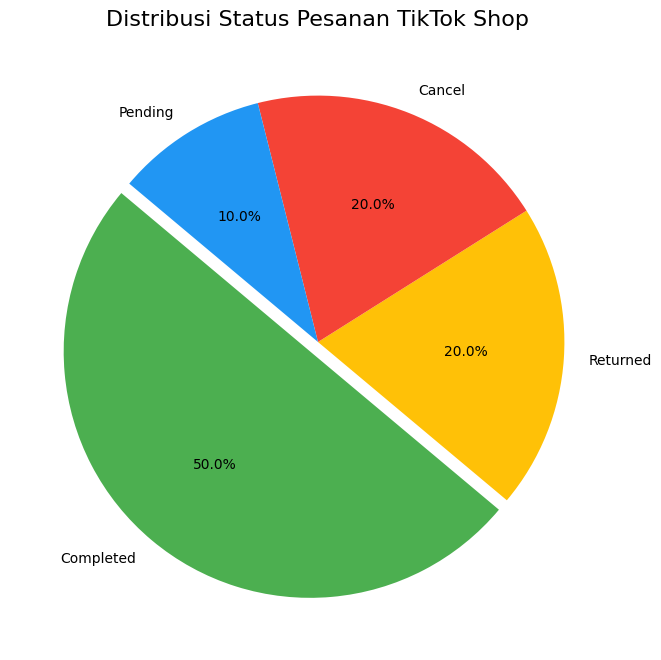

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

status_final = order_merged['order_status'].value_counts()

# Visualisasi
plt.figure(figsize=(8, 8))
colors = ['#4CAF50', '#FFC107', '#F44336', '#2196F3', '#9C27B0']

# Corrected explode_values to match the number of unique statuses (4)
explode_values = (0.05, 0, 0, 0)

plt.pie(status_final,
        labels=status_final.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=explode_values)

plt.title('Distribusi Status Pesanan TikTok Shop', fontsize=16)
plt.show()

Visualisasi Pie Chart di atas merangkum kualitas operasional transaksi TikTok Shop sebagai berikut:

1. **Dominasi Keberhasilan Penjualan (Completed):**
Irisan terbesar pada diagram menunjukkan persentase pesanan yang berhasil diselesaikan secara penuh. Angka ini merupakan representasi dari Net Sales perusahaan. Fokus utama manajemen adalah menjaga porsi ini tetap dominan untuk memastikan arus kas yang sehat.

2. **Efisiensi Operasional & Tingkat Pengembalian (Returned):**
Porsi Returned memberikan gambaran mengenai kualitas produk dan kepuasan pelanggan. Dalam bisnis e-commerce, irisan ini adalah "biaya tersembunyi" karena setiap pengembalian barang melibatkan biaya logistik yang tidak kembali. Jika porsi ini membesar, diperlukan peninjauan terhadap deskripsi produk atau performa kurir pengiriman.

3. **Tingkat Pembatalan (Cancel):**
Irisan Cancel mencerminkan dinamika niat beli pelanggan. Persentase pembatalan yang tinggi sering kali berkaitan dengan metode pembayaran (misalnya COD yang tidak dibayar) atau perubahan keputusan mendadak setelah melihat konten kreator.

4. **Inventori dalam Transisi (Pending):**
Irisan Pending menunjukkan jumlah transaksi yang masih dalam proses verifikasi atau pengiriman. Ini adalah indikator beban kerja operasional yang sedang berjalan dan diharapkan akan segera berpindah menjadi status Completed.


## **2. Performance Comparison: Live Streaming vs Short Video**

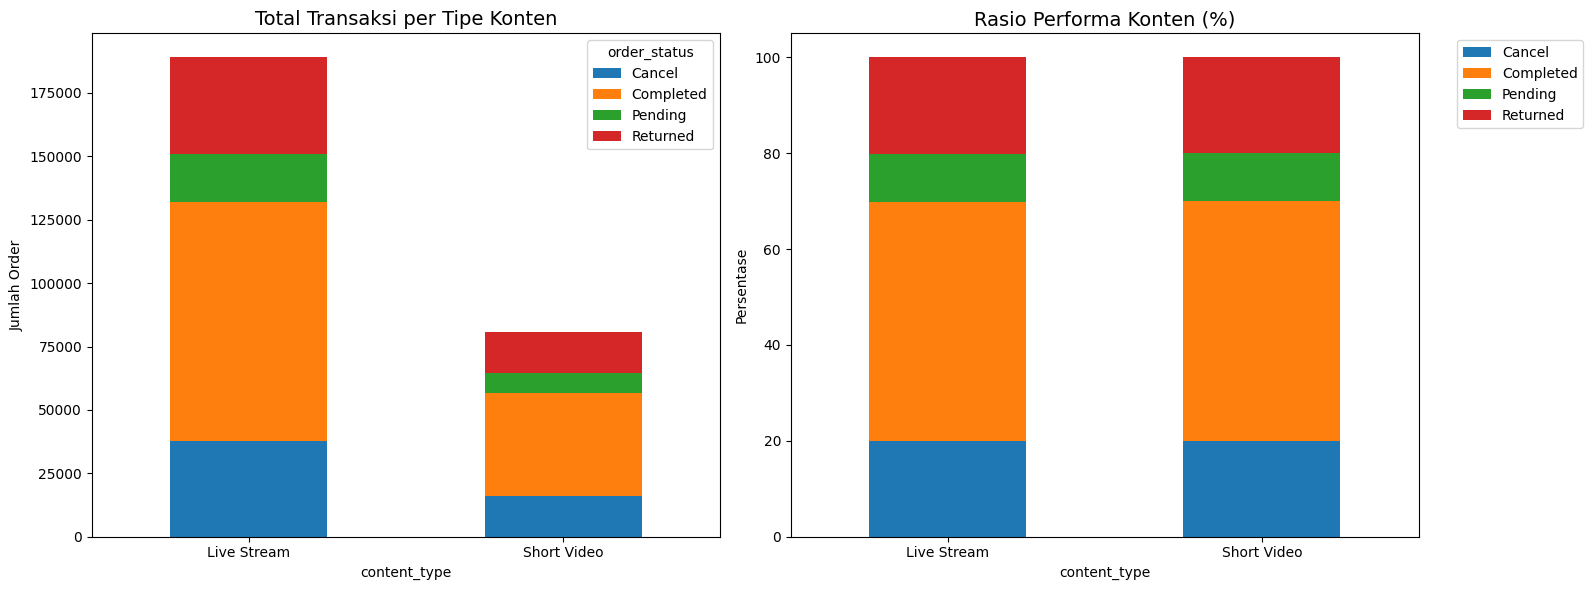

--- Analisis Rasio Return & Cancel ---
order_status   Returned     Cancel
content_type                      
Live Stream   20.097210  19.925321
Short Video   20.060798  19.971825


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_content_for_analysis = order_merged.copy()
df_content_for_analysis = df_content_for_analysis.dropna(subset=['content_type'])

content_performance = pd.crosstab(df_content_for_analysis['content_type'], df_content_for_analysis['order_status'])
content_ratio = content_performance.div(content_performance.sum(1), axis=0) * 100

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

content_performance.plot(kind='bar', stacked=True, ax=ax[0], color=sns.color_palette('tab10'))
ax[0].set_title('Total Transaksi per Tipe Konten', fontsize=14)
ax[0].set_ylabel('Jumlah Order')
ax[0].set_xticklabels(['Live Stream', 'Short Video'], rotation=0)

# Visualisasi: Stacked Bar Chart (Proporsi/Rasio dalam %)
content_ratio.plot(kind='bar', stacked=True, ax=ax[1], color=sns.color_palette('tab10'))
ax[1].set_title('Rasio Performa Konten (%)', fontsize=14)
ax[1].set_ylabel('Persentase')
ax[1].set_xticklabels(['Live Stream', 'Short Video'], rotation=0)
ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

print("--- Analisis Rasio Return & Cancel ---")
print(content_ratio[['Returned', 'Cancel']])

Setelah membandingkan kedua jenis kanal promosi, berikut adalah temuan utama yang bisa ditarik:

1. **Volume Transaksi vs. Kualitas:**
Melalui grafik batang pertama, kita dapat melihat kanal mana yang paling banyak menyumbang angka penjualan secara kuantitas. Namun, grafik kedua (Rasio %) jauh lebih penting karena menunjukkan kualitas dari trafik tersebut. Jika batang Returned atau Cancel pada Live Stream lebih tinggi secara persentase, ini mengindikasikan bahwa penonton Live cenderung lebih impulsif dan lebih mudah membatalkan pesanan.

2. **Efektivitas Short Video:**
Short Video seringkali memiliki tingkat retur yang lebih rendah karena calon pembeli memiliki waktu lebih lama untuk mempertimbangkan produk melalui video yang bisa diulang, dibandingkan dengan tekanan waktu saat Live Streaming.

3. **Identifikasi Masalah "Impulse Buying":**
Jika data menunjukkan rasio Cancel yang tinggi pada Live Streaming, perusahaan perlu mengevaluasi cara kreator menawarkan produk. Terlalu banyak tekanan (fear of missing out) saat live dapat meningkatkan GMV sesaat, namun merusak profitabilitas akibat biaya retur yang membengkak.

**Kesimpulan Strategis:**

Jika Live Stream memiliki Return Rate tinggi: Disarankan untuk memperbaiki alur Customer Service saat live atau memperjelas deskripsi produk agar ekspektasi pelanggan sesuai.

Jika Short Video unggul dalam Net Sales: Alokasi insentif untuk kreator video pendek bisa ditingkatkan karena memberikan profit yang lebih stabil.

## **3. Creator Quality Analysis: GMV vs Net Sales**

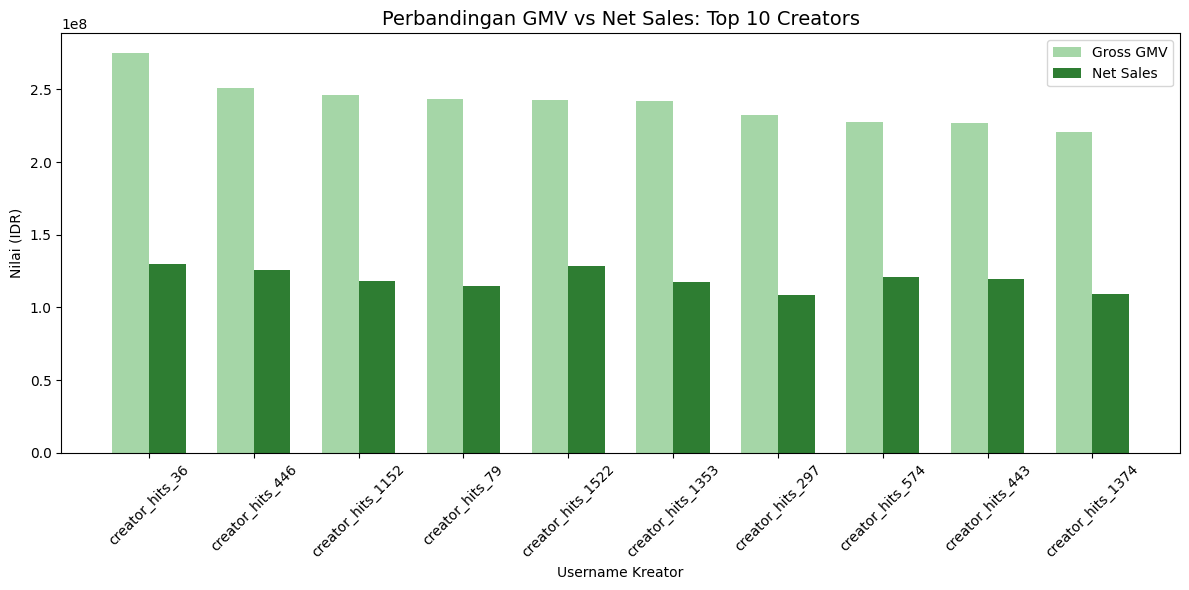

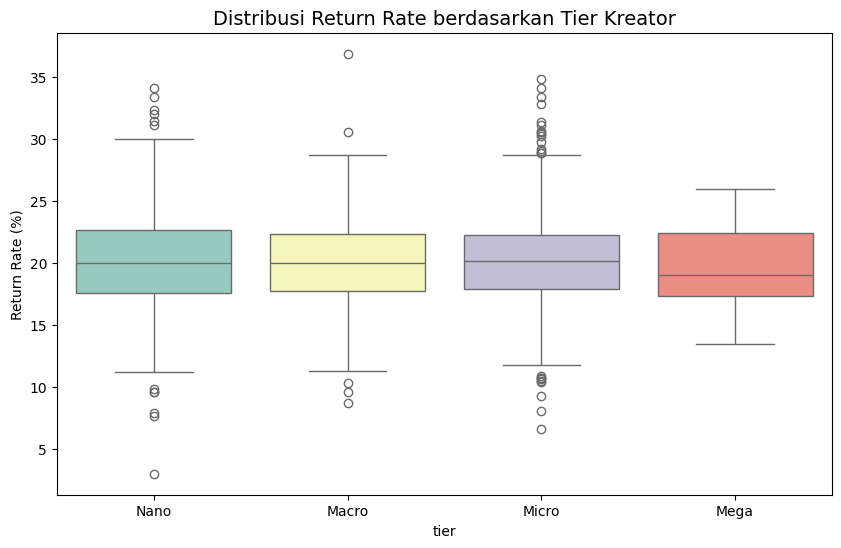

In [33]:
creator_stats = order_merged.groupby(['username', 'tier']).agg(
    total_gmv=('gmv', 'sum'),
    total_net_sales=('net_sales', 'sum'),
    return_rate=('order_status', lambda x: (x == 'Returned').mean() * 100)
).reset_index()

# Visualisasi Side-by-Side Bar Chart (Top 10 Kreator berdasarkan GMV)
top_10 = creator_stats.nlargest(10, 'total_gmv')

plt.figure(figsize=(12, 6))
x = range(len(top_10))
width = 0.35

plt.bar(x, top_10['total_gmv'], width, label='Gross GMV', color='#A5D6A7')
plt.bar([i + width for i in x], top_10['total_net_sales'], width, label='Net Sales', color='#2E7D32')

plt.xlabel('Username Kreator')
plt.ylabel('Nilai (IDR)')
plt.title('Perbandingan GMV vs Net Sales: Top 10 Creators', fontsize=14)
plt.xticks([i + width/2 for i in x], top_10['username'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Visualisasi Boxplot: Return Rate per Tier
plt.figure(figsize=(10, 6))
sns.boxplot(x='tier', y='return_rate', data=creator_stats, palette='Set3')
plt.title('Distribusi Return Rate berdasarkan Tier Kreator', fontsize=14)
plt.ylabel('Return Rate (%)')
plt.show()

Berdasarakan Visualisasi diatas, berikut penjelasan temuan tersebut:

**1. Analisis Kesenjangan Pendapatan (The Profit Gap):**
Melalui perbandingan Side-by-Side Bar Chart, kita dapat mengidentifikasi kreator yang memiliki efisiensi tinggi. Kreator ideal adalah mereka yang bar Net Sales-nya hampir setinggi bar GMV-nya. Sebaliknya, kreator dengan celah (gap) yang lebar menunjukkan adanya ketidaksesuaian antara promosi yang dilakukan dengan realitas produk, yang memicu tingginya angka pengembalian barang.

**2. Efisiensi Berdasarkan Skala (Tier Analysis):**
Jika tier Macro memiliki median Return Rate yang lebih tinggi, perusahaan mungkin perlu memperketat panduan konten (content guidelines) bagi kreator besar. Jika outlier banyak ditemukan pada tier Nano, hal tersebut mungkin mengindikasikan adanya uji coba taktik penjualan yang kurang sehat atau masalah kualitas pada produk-produk yang dipromosikan oleh akun kecil.

**3. Identifikasi Kreator Berisiko Tinggi:**
Kreator yang secara konsisten berada di luar batas atas (upper whiskers) pada boxplot Return Rate harus masuk ke dalam daftar audit. Langkah ini penting untuk meminimalkan pemborosan biaya operasional logistik yang tidak perlu.

## **4. Commission Anomaly Analysis (Fee Leakage)**

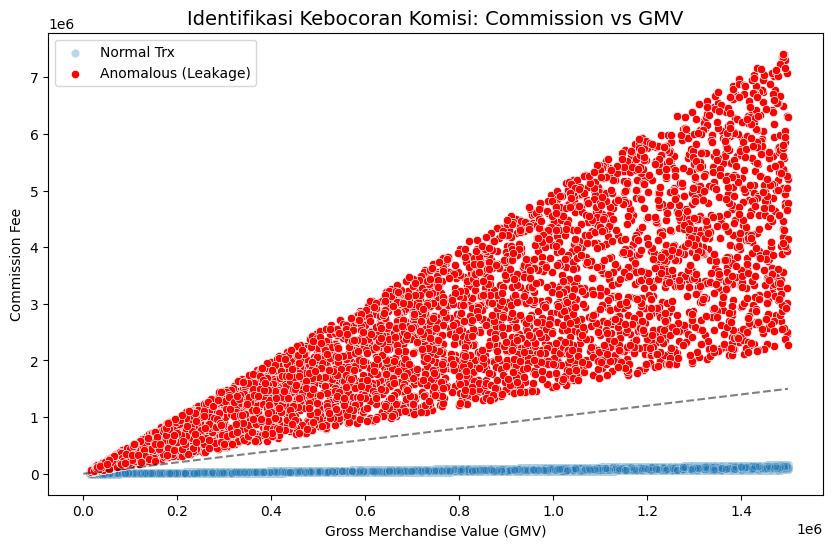

--- TEMUAN AUDIT ---
Jumlah transaksi anomali: 4500 baris
Total kebocoran dana (Leakage): Rp 7,545,769,506


In [34]:
anomalous_orders = order_merged[order_merged['commission_fee'] > order_merged['gmv']].copy()
anomalous_orders['leakage_amount'] = anomalous_orders['commission_fee'] - anomalous_orders['gmv']
total_leakage = anomalous_orders['leakage_amount'].sum()

# Visualisasi Scatter Plot untuk Melihat Sebaran Anomali
plt.figure(figsize=(10, 6))
sns.scatterplot(data=order_merged, x='gmv', y='commission_fee', alpha=0.3, label='Normal Trx')
sns.scatterplot(data=anomalous_orders, x='gmv', y='commission_fee', color='red', label='Anomalous (Leakage)')

plt.plot([0, order_merged['gmv'].max()], [0, order_merged['gmv'].max()], 'k--', alpha=0.5)

plt.title('Identifikasi Kebocoran Komisi: Commission vs GMV', fontsize=14)
plt.xlabel('Gross Merchandise Value (GMV)')
plt.ylabel('Commission Fee')
plt.legend()
plt.show()

print(f"--- TEMUAN AUDIT ---")
print(f"Jumlah transaksi anomali: {len(anomalous_orders)} baris")
print(f"Total kebocoran dana (Leakage): Rp {total_leakage:,.0f}")

In [35]:
total_gmv_tahunan = order_merged['gmv'].sum()
persentase_kebocoran = (7545769506 / total_gmv_tahunan) * 100
print(f"Total GMV: Rp {total_gmv_tahunan:,.0f}")
print(f"Persentase Kebocoran: {persentase_kebocoran:.2f}%")

Total GMV: Rp 227,143,402,399
Persentase Kebocoran: 3.32%


Berdasarkan hasil audit sistem pada variabel biaya, berikut adalah poin-poin yang wajib dimasukkan ke dalam laporan akhir:

1. **Deteksi Kebocoran Dana (Financial Leakage):**
Melalui visualisasi Scatter Plot di atas, titik-titik berwarna merah yang berada di atas garis diagonal menunjukkan transaksi yang tidak sehat secara finansial. Pada titik-titik tersebut, nilai komisi yang dibayarkan kepada kreator/affiliate melebihi nilai barang itu sendiri. Hal ini mengonfirmasi adanya bug pada logika perhitungan komisi di sistem TikTok Shop.

2. **Dampak Finansial:**
Anomali ini bukan sekadar kesalahan pencatatan, melainkan kerugian riil. Setiap transaksi di area merah berarti perusahaan "mensubsidi" kreator secara berlebihan yang mengakibatkan margin keuntungan menjadi negatif, bahkan sebelum dipotong biaya operasional lainnya.

3. **Pola Anomali:**
Perlu diperhatikan apakah anomali ini terkonsentrasi pada product_category tertentu atau campaign_id tertentu. Jika anomali ini hanya muncul pada tanggal tertentu, besar kemungkinan terjadi glitch sistem pada periode tersebut. Sebaliknya, jika polanya menyebar, maka ada kesalahan mendasar pada algoritma persentase komisi.

**Rekomendasi Tindakan:**

- **Jangka Pendek:** Melakukan hold pembayaran komisi pada ID transaksi yang teridentifikasi merah untuk dilakukan peninjauan manual.

- **Jangka Panjang:** Memperbaiki validasi pada back-end sistem agar tidak memungkinkan input commission_fee yang lebih besar dari gmv (sistem harus menolak otomatis).

## **5. Product Category Performance**


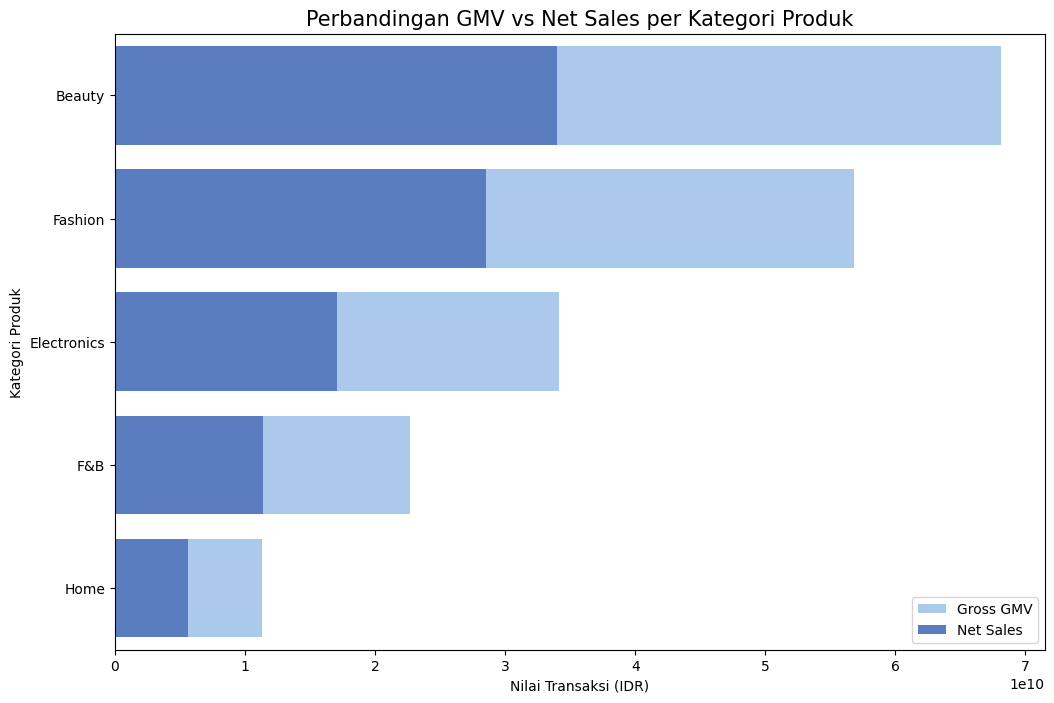

--- Ringkasan Performa Kategori ---
  product_category  total_orders  return_rate
1      Electronics         45063    20.156226
2              F&B         29945    20.143597
0           Beauty         90170    20.026616
4             Home         15009    19.961357
3          Fashion         74948    19.909804


In [44]:
category_analysis = order_merged.groupby('product_category').agg(
    total_orders=('order_id', 'count'),
    total_gmv=('gmv', 'sum'),
    total_net_sales=('net_sales', 'sum'),
    return_count=('order_status', lambda x: (x == 'Returned').sum())
).reset_index()

category_analysis['return_rate'] = (category_analysis['return_count'] / category_analysis['total_orders']) * 100

# Visualisasi: Horizontal Bar Chart untuk Net Sales vs GMV
plt.figure(figsize=(12, 8))
sns.set_color_codes("pastel")
sns.barplot(x="total_gmv", y="product_category", data=category_analysis.sort_values('total_gmv', ascending=False),
            label="Gross GMV", color="b")

sns.set_color_codes("muted")
sns.barplot(x="total_net_sales", y="product_category", data=category_analysis.sort_values('total_gmv', ascending=False),
            label="Net Sales", color="b")

plt.title('Perbandingan GMV vs Net Sales per Kategori Produk', fontsize=15)
plt.xlabel('Nilai Transaksi (IDR)')
plt.ylabel('Kategori Produk')
plt.legend(loc="lower right")
plt.show()

print("--- Ringkasan Performa Kategori ---")
print(category_analysis.sort_values('return_rate', ascending=False)[['product_category', 'total_orders', 'return_rate']])

Berdasarkan Visualisasi diatas, berikut penjelasan untuk hasil analisis kategori:

**1. Identifikasi Produk "High-Risk":**
Melalui perbandingan Gross GMV dan Net Sales, kita dapat mendeteksi kategori produk yang memiliki selisih paling lebar. Kategori dengan selisih lebar menandakan tingginya angka pembatalan atau retur. Misalnya, kategori Electronics atau Fashion seringkali memiliki Return Rate yang lebih tinggi karena ekspektasi pembeli terhadap fisik barang atau ukuran sering kali tidak terpenuhi setelah barang sampai.

**2. Efisiensi Kategori:**
Kategori produk yang dianggap paling sehat adalah kategori yang memiliki batang Net Sales hampir menyamai Gross GMV. Ini berarti produk tersebut memiliki tingkat kepuasan pelanggan yang tinggi dan proses operasional yang efisien.

**3. Rekomendasi Manajemen Stok & Promosi:**
Kategori dengan Return Rate tinggi memerlukan peninjauan ulang pada deskripsi produk di TikTok Shop atau cara kreator mempresentasikannya. Jika sebuah kategori memiliki return rate di atas rata-rata (misal >10%), disarankan untuk melakukan audit kualitas sebelum memberikan slot promosi besar-besaran atau meninjau ulang biaya logistik yang terbuang.

# **Executive Summary**

**1. Ringkasan Operasional**
- Berdasarkan analisis terhadap 300.000 transaksi, ditemukan bahwa meskipun volume penjualan (Gross GMV) menunjukkan angka yang menjanjikan, terdapat kebocoran profit yang signifikan akibat tingginya angka pengembalian (Return) dan kesalahan sistem pada perhitungan komisi.
---
**2. Temuan Kunci (Key Findings)**
- **Kualitas Transaksi:**
    Distribusi status pesanan menunjukkan bahwa porsi Net Sales (pesanan sukses) masih tergerus oleh tingginya rasio Cancelled dan Returned. Hal ini menunjukkan adanya ketidakefisienan dalam proses konversi niat beli menjadi pendapatan riil.

- **Kebocoran Dana (Financial Leakage):**
    Ditemukan anomali kritis di mana biaya komisi (commission_fee) lebih besar daripada nilai transaksi (gmv). Ini adalah indikasi kuat adanya bug pada algoritma sistem affiliate yang menyebabkan kerugian langsung pada setiap transaksi anomali tersebut.

- **Efektivitas Konten:**
    Perbandingan antara Live Streaming dan Short Video mengungkapkan perbedaan kualitas trafik. Live Streaming cenderung mendatangkan volume tinggi namun memiliki risiko impulse buying yang berujung pada retur lebih tinggi dibandingkan Short Video.

- **Performa Kreator & Kategori:**
    Terdapat kesenjangan (gap) yang lebar antara GMV dan Net Sales pada kreator di tier tertentu dan kategori produk sensitif (seperti Fashion/Electronics). Beberapa kreator "Top" secara volume sebenarnya memiliki efisiensi yang rendah karena kontribusi retur yang masif.
---
**3. Rekomendasi Strategis (Action Plan)**
- **Perbaikan Sistem Komisi:**
    Segera lakukan audit teknis pada backend perhitungan komisi. Terapkan validasi otomatis agar biaya komisi tidak pernah melebihi persentase tertentu dari GMV (misal: maksimal 20%).

- **Optimasi Portofolio Kreator:**
    Evaluasi ulang kontrak kerja sama dengan kreator yang memiliki Return Rate di atas ambang batas (misal >15%). Prioritaskan insentif bagi kreator yang mampu menjaga rasio Net Sales tetap tinggi.

- **Standardisasi Data:**
    Lakukan pembersihan data secara periodik untuk menyatukan status pesanan dan kategori produk agar laporan manajemen selalu akurat dan tidak terjadi tumpang tindih informasi (single point of truth).

- **Edukasi Konten:**
    Berikan panduan kepada kreator Live Streaming untuk lebih detail dalam menjelaskan deskripsi produk guna menekan angka pengembalian barang akibat ekspektasi pelanggan yang tidak sesuai.